In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sys

sys.path.append("../")

In [2]:
data = np.load('../data/processed/train_test_split.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']


In [3]:
from src.model_trainer import FraudModelTrainer

log_model = FraudModelTrainer("logistic")
log_model.train(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)
print("logistic", y_pred_log, y_proba_log)


xgb_model = FraudModelTrainer("xgboost")
xgb_model.train(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)
print("xgb", y_pred_xgb, y_proba_xgb)

random_model = FraudModelTrainer("random_forest")
random_model.train(X_train, y_train)
y_pred_random = random_model.predict(X_test)
y_proba_random = random_model.predict_proba(X_test)
print("random", y_pred_random, y_proba_random)

logistic [0 0 1 ... 0 0 0] [0.21097298 0.20450507 0.53297285 ... 0.26766636 0.26323468 0.29861081]


c:\Users\hp\Desktop\Projects\ML\KAIM\week-8-9\transaction-fraud-detector\env\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:40:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


xgb [0 0 0 ... 0 0 0] [0.02715546 0.03345359 0.22249967 ... 0.06723829 0.05777595 0.06464523]
random [0 0 0 ... 0 0 0] [0.02 0.05 0.19 ... 0.06 0.03 0.14]



📊 Evaluation Metrics for Logistic Regression:
F1 Score: 0.6048
AUC-PR: 0.6667
AUC-ROC: 0.8415


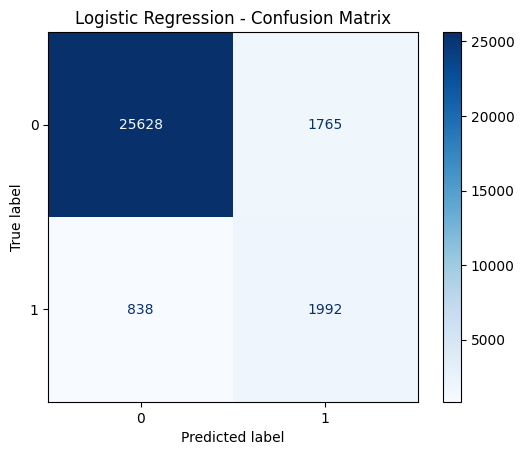

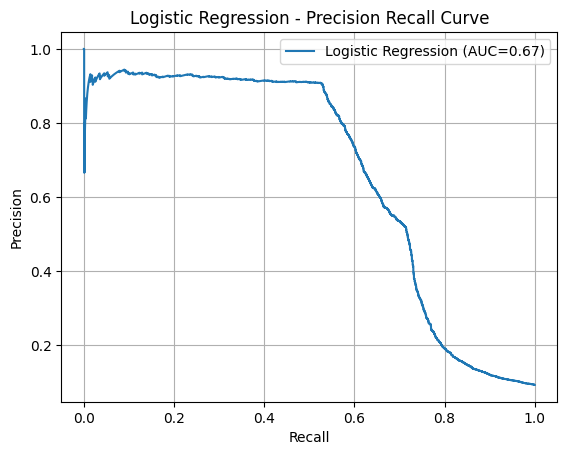

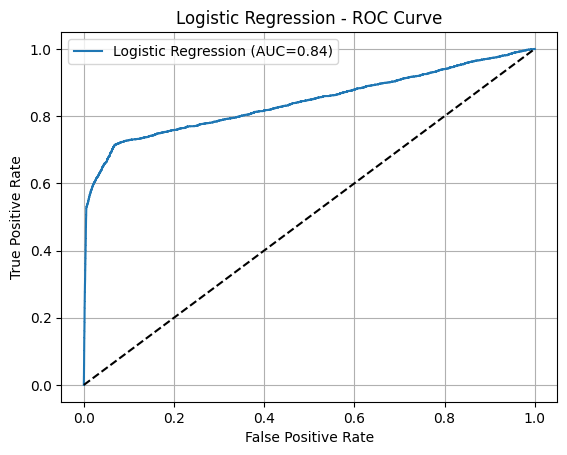


📊 Evaluation Metrics for XGBoost:
F1 Score: 0.6789
AUC-PR: 0.7065
AUC-ROC: 0.8419


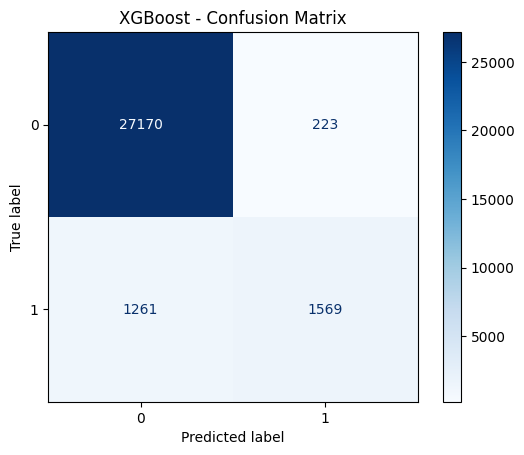

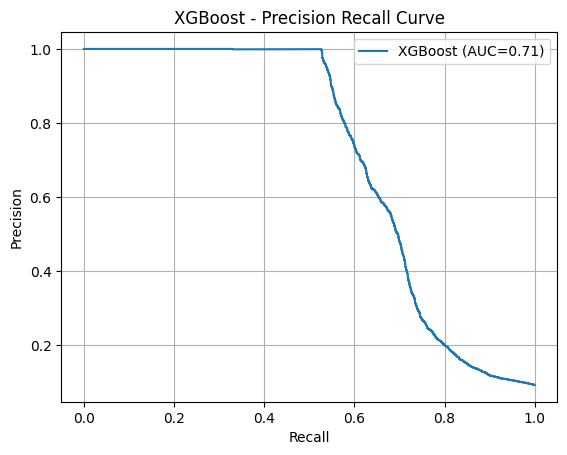

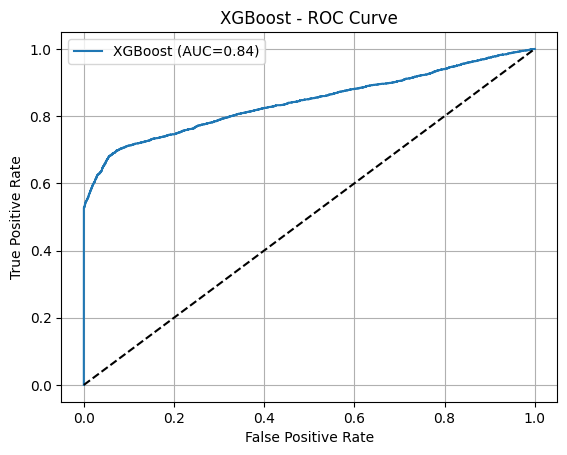


📊 Evaluation Metrics for random_forest:
F1 Score: 0.6731
AUC-PR: 0.6942
AUC-ROC: 0.8402


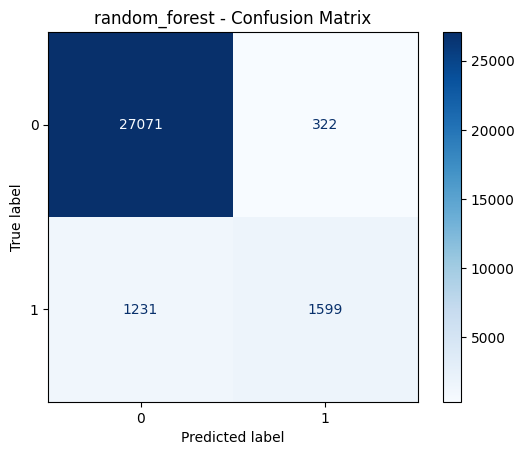

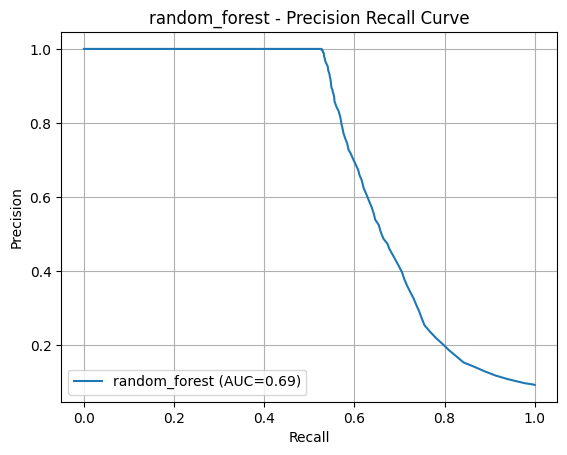

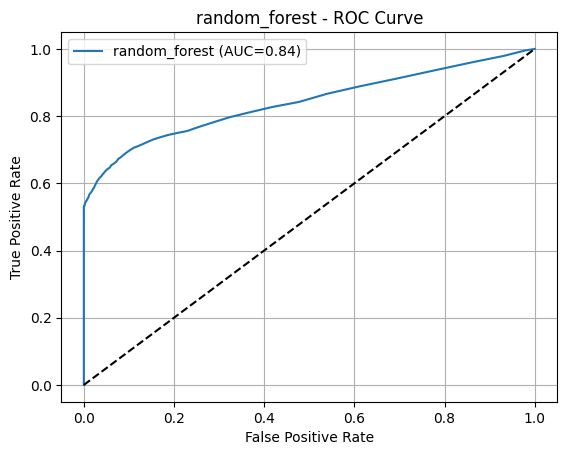

In [4]:
from src.model_eval import ModelEvaluator

# Logistic Regression
eval_log = ModelEvaluator(y_test, y_pred_log, y_proba_log, model_name="Logistic Regression")
eval_log.print_metrics()
eval_log.plot_confusion_matrix()
eval_log.plot_precision_recall()
eval_log.plot_roc_curve()

# XGBoost
eval_xgb = ModelEvaluator(y_test, y_pred_xgb, y_proba_xgb, model_name="XGBoost")
eval_xgb.print_metrics()
eval_xgb.plot_confusion_matrix()
eval_xgb.plot_precision_recall()
eval_xgb.plot_roc_curve()

#random
eval_random = ModelEvaluator(y_test, y_pred_random, y_proba_random, model_name="random_forest")
eval_random.print_metrics()
eval_random.plot_confusion_matrix()
eval_random.plot_precision_recall()
eval_random.plot_roc_curve()

### Explain model with SHAP

c:\Users\hp\Desktop\Projects\ML\KAIM\week-8-9\transaction-fraud-detector\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


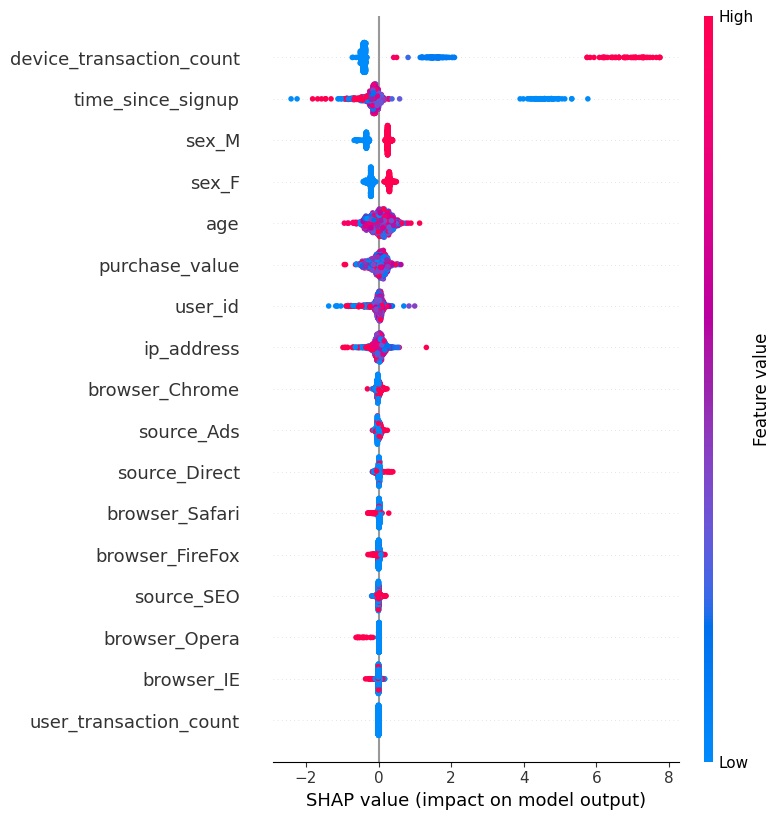

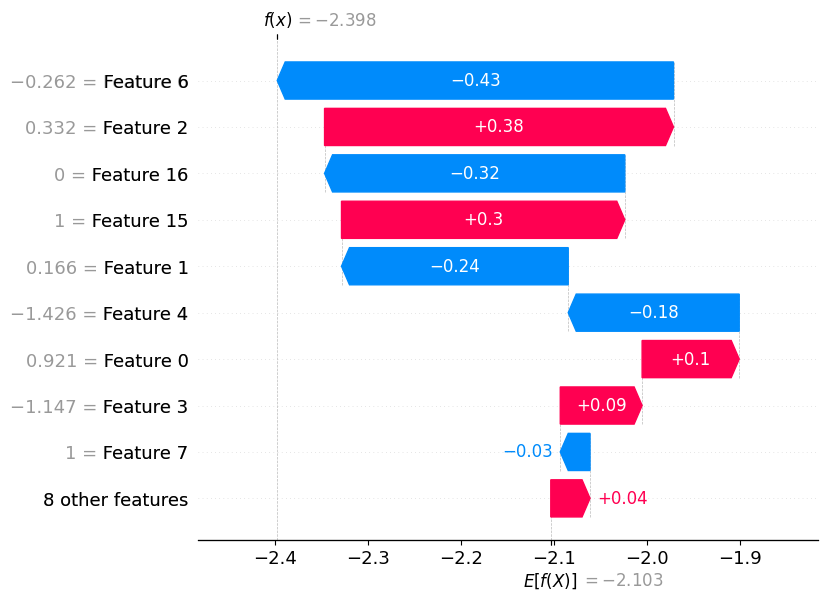

In [5]:
from  src.model_explain import SHAPInterpreter

model = xgb_model.get_model()

X_sample = X_train[:1000]
feature_names = ['user_id',
 'purchase_value',
 'age',
 'ip_address',
 'time_since_signup',
 'user_transaction_count',
 'device_transaction_count',
 'source_Ads',
 'source_Direct',
 'source_SEO',
 'browser_Chrome',
 'browser_FireFox',
 'browser_IE',
 'browser_Opera',
 'browser_Safari',
 'sex_F',
 'sex_M']

shap_vis = SHAPInterpreter(model, X_sample, feature_names)
shap_vis.summary()
shap_vis.force(0)
shap_vis.waterfall(0)
